# Handling missing categorical data

In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [43]:
data = pd.read_csv('../../datasets/train.csv')

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [5]:
data.head(5)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [8]:
data = data[['SalePrice','FireplaceQu','GarageQual']]

In [9]:
data.head(5)

,SalePrice,FireplaceQu,GarageQual
0,208500,NaN,TA
1,181500,TA,TA
2,223500,TA,TA
3,140000,Gd,TA
4,250000,TA,TA


In [10]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   SalePrice    1460 non-null   int64 
 1   FireplaceQu  770 non-null    object
 2   GarageQual   1379 non-null   object
dtypes: int64(1), object(2)
memory usage: 34.3+ KB


In [11]:
data.isnull().sum()

SalePrice        0
FireplaceQu    690
GarageQual      81
dtype: int64

In [12]:
data.isnull().mean()*100

SalePrice       0.000000
FireplaceQu    47.260274
GarageQual      5.547945
dtype: float64

<Axes: xlabel='GarageQual'>

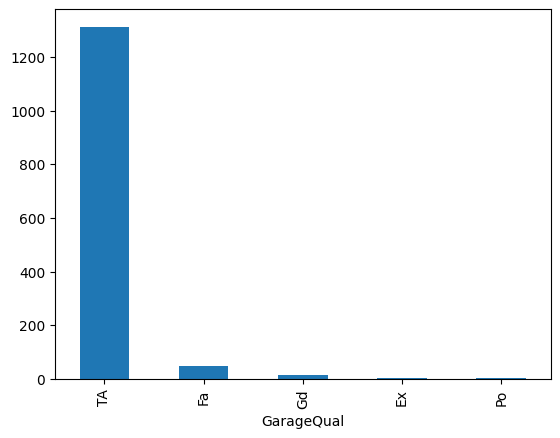

In [13]:
data['GarageQual'].value_counts().plot(kind='bar')

In [15]:
data['GarageQual'].mode()

0    TA
Name: GarageQual, dtype: object

Text(0.5, 1.0, 'GarageQual')

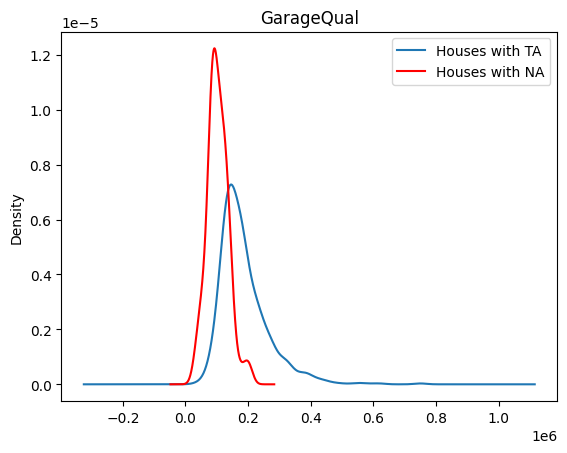

In [18]:
# data before handling missing values
fig = plt.figure()
ax = fig.add_subplot(111)

data[data['GarageQual']=='TA']['SalePrice'].plot(kind='kde',ax=ax)
data[data['GarageQual'].isnull()]['SalePrice'].plot(kind='kde',ax=ax,color='red')
lines, labels = ax.get_legend_handles_labels()
labels = ['Houses with TA', 'Houses with NA']
ax.legend(lines, labels, loc='best')

plt.title('GarageQual')

In [21]:
temp = data[data['GarageQual']=='TA']['SalePrice']

In [22]:
temp.head(5)

0    208500
1    181500
2    223500
3    140000
4    250000
Name: SalePrice, dtype: int64

In [23]:
data['GarageQual'].fillna('TA',inplace=True)

C:\Users\dspri\AppData\Local\Temp\ipykernel_29172\1915291151.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['GarageQual'].fillna('TA',inplace=True)
C:\Users\dspri\AppData\Local\Temp\ipykernel_29172\1915291151.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['GarageQual'].fillna('TA',inplace=True)


In [24]:
data.isnull().sum()

SalePrice        0
FireplaceQu    690
GarageQual       0
dtype: int64

<Axes: xlabel='GarageQual'>

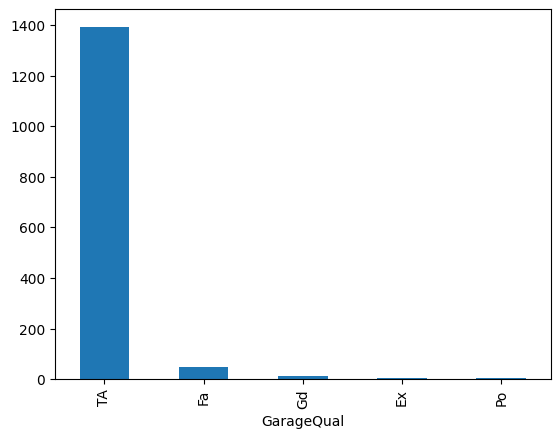

In [26]:
data['GarageQual'].value_counts().plot(kind='bar')

<Axes: ylabel='Density'>

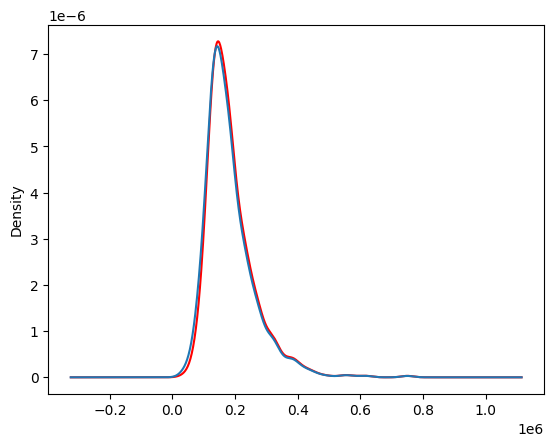

In [28]:
fig = plt.figure()
ax = fig.add_subplot(111)

temp.plot(kind='kde',color='red',ax=ax)

data[data['GarageQual']=='TA']['SalePrice'].plot(kind='kde',ax=ax)

In [30]:
data['FireplaceQu'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 1460 entries, 0 to 1459
Series name: FireplaceQu
Non-Null Count  Dtype 
--------------  ----- 
770 non-null    object
dtypes: object(1)
memory usage: 11.5+ KB


In [33]:
data['FireplaceQu'].isnull()

0        True
1       False
2       False
3       False
4       False
        ...  
1455    False
1456    False
1457    False
1458     True
1459     True
Name: FireplaceQu, Length: 1460, dtype: bool

In [32]:
data['FireplaceQu'].value_counts()

FireplaceQu
Gd    380
TA    313
Fa     33
Ex     24
Po     20
Name: count, dtype: int64

<Axes: xlabel='FireplaceQu'>

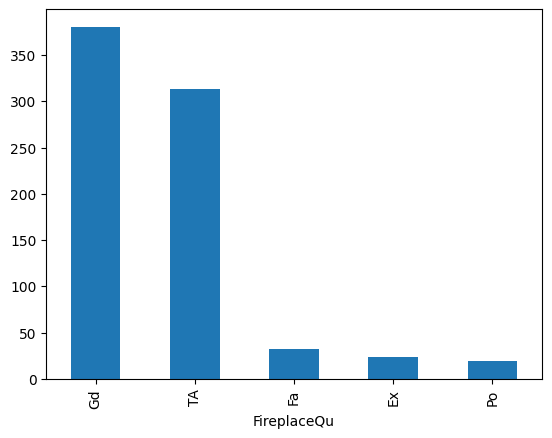

In [29]:
data['FireplaceQu'].value_counts().plot(kind='bar')

In [34]:
data['FireplaceQu'].mode()

0    Gd
Name: FireplaceQu, dtype: object

<Axes: ylabel='Density'>

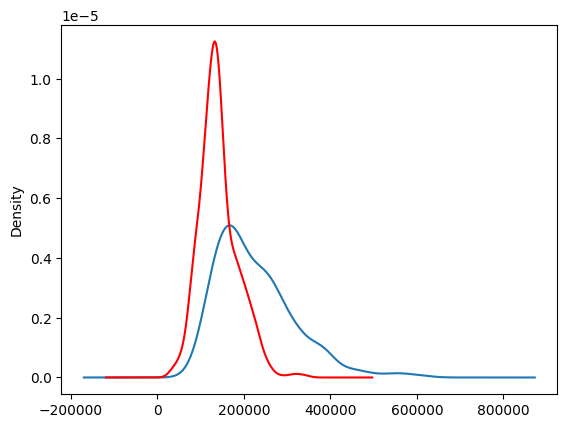

In [36]:
fig = plt.figure()
ax = fig.add_subplot(111)

data[data['FireplaceQu']=='Gd']['SalePrice'].plot(kind='kde',ax=ax)

data[data['FireplaceQu'].isnull()]['SalePrice'].plot(kind='kde',ax=ax,color='red')

In [37]:
temp = data[data['FireplaceQu']=='Gd']['SalePrice']

In [38]:
temp

3       140000
6       307000
11      345000
13      279500
20      325300
         ...  
1437    394617
1440    191000
1443    121000
1451    287090
1457    266500
Name: SalePrice, Length: 380, dtype: int64

In [39]:
data['FireplaceQu'].fillna('Gd',inplace=True)

C:\Users\dspri\AppData\Local\Temp\ipykernel_29172\3235380212.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['FireplaceQu'].fillna('Gd',inplace=True)
C:\Users\dspri\AppData\Local\Temp\ipykernel_29172\3235380212.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['FireplaceQu'].fillna('Gd',inplace=True)


<Axes: xlabel='FireplaceQu'>

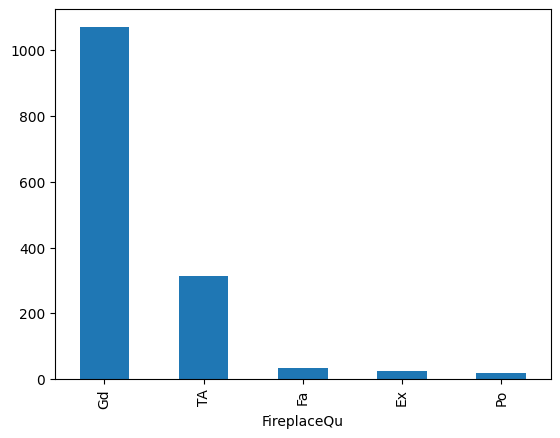

In [40]:
data['FireplaceQu'].value_counts().plot(kind='bar')

<Axes: ylabel='Density'>

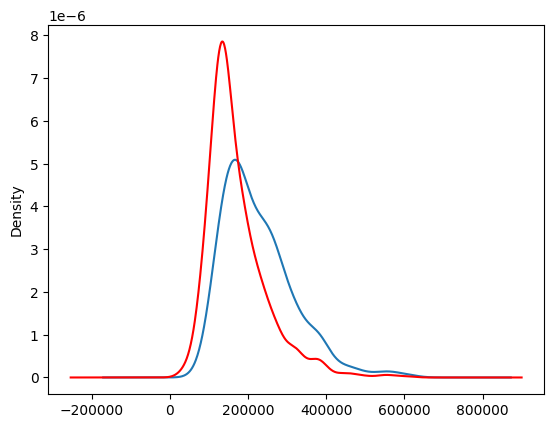

In [41]:
fig = plt.figure()
ax = fig.add_subplot(111)
temp.plot(kind='kde',ax=ax)

data[data['FireplaceQu']=='Gd']['SalePrice'].plot(kind='kde',ax=ax,color='red')

In [44]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(data.drop(columns=['SalePrice']),data['SalePrice'],test_size=0.3,random_state=42)

In [45]:
from sklearn.impute import SimpleImputer

In [49]:
imputer = SimpleImputer(strategy='most_frequent')

In [50]:
x_train = imputer.fit_transform(x_train)
x_test = imputer.fit_transform(x_test)

In [51]:
imputer.statistics_

array([11, 20, 'RL', 60.0, 7200, 'Pave', 'Pave', 'Reg', 'Lvl', 'AllPub',
       'Inside', 'Gtl', 'NAmes', 'Norm', 'Norm', '1Fam', '1Story', 5, 5,
       2006, 1950, 'Gable', 'CompShg', 'VinylSd', 'VinylSd', 'BrkFace',
       0.0, 'TA', 'TA', 'CBlock', 'TA', 'TA', 'No', 'Unf', 0, 'Unf', 0, 0,
       864, 'GasA', 'Ex', 'Y', 'SBrkr', 864, 0, 0, 864, 0, 0, 2, 0, 3, 1,
       'TA', 6, 'Typ', 1, 'Gd', 'Attchd', 2005.0, 'Unf', 2, 0, 'TA', 'TA',
       'Y', 0, 0, 0, 0, 0, 0, 'Fa', 'MnPrv', 'Shed', 0, 6, 2007, 'WD',
       'Normal'], dtype=object)